# Start of the Sensitivity Analysis of the RCMs 

Program to read in the zarr collection of an RCM and its corresponding FFDI files and explore FFDI drivers


3-23-.10




#### required packages

In [47]:
import intake
import xarray as xr
from matplotlib import pyplot as plt
import numpy as np

from glob import glob
import pathlib
import traceback
from datetime import datetime

from xclim.indices import (
    keetch_byram_drought_index,
    griffiths_drought_factor,
    mcarthur_forest_fire_danger_index
)

%load_ext autoreload
%autoreload 2


# importing sys
import sys
# adding plotting module to the system path
sys.path.insert(0, '/g/data/xv83/rxm599/acs/plotting_maps')
# import ACS plotting maps and Xarray.
from acs_plotting_maps import *
from acs_area_statistics import acs_regional_stats, get_regions

import geopandas as gpd
import pandas as pd
import regionmask

sys.path.insert(0, '/g/data/xv83/rxm599/acs/hazard_fire/paper2')
import sa as sa


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### start a local Dask client

In [2]:
from dask.distributed import Client
import dask

# Set configuration options
dask.config.set({
    'distributed.comm.timeouts.connect': '90s',  # Timeout for connecting to a worker
    'distributed.comm.timeouts.tcp': '90s',  # Timeout for TCP communications
})

#cluster = LocalCluster(
#    n_workers=28,          # Number of workers
#    threads_per_worker=1 #Threads per worker
#    #memory_limit='8GB' # Memory limit per each worker commented out
#)
#client = Client(cluster)

client = Client()
client

2025-08-15 11:11:33,382 - distributed.preloading - INFO - Creating preload: /g/data/hh5/public/apps/dask-optimiser/schedplugin.py
2025-08-15 11:11:33,389 - distributed.utils - INFO - Reload module schedplugin from .py file
2025-08-15 11:11:33,436 - distributed.preloading - INFO - Import preload module: /g/data/hh5/public/apps/dask-optimiser/schedplugin.py


Modifying workers


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /node/gadi-cpu-bdw-0072.gadi.nci.org.au/2716/proxy/8787/status,
Dashboard: /node/gadi-cpu-bdw-0072.gadi.nci.org.au/2716/proxy/8787/status,Workers: 2
Total threads: 2,Total memory: 0 B
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33561,Workers: 2
Dashboard: /node/gadi-cpu-bdw-0072.gadi.nci.org.au/2716/proxy/8787/status,Total threads: 2
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43143,Total threads: 1
Dashboard: /node/gadi-cpu-bdw-0072.gadi.nci.org.au/2716/proxy/41983/status,Memory: 0 B
Nanny: tcp://127.0.0.1:43037,


In [3]:
import warnings
warnings.filterwarnings('ignore')

## Set parameters

In [88]:
# parameters
# 0,2,3 failed
mindex=0
#lon1=140; lon2=150 
#lat1=-45; lat2= -32
#lat1=-45 lat2= -40 lon1=144 lon2=149
#lon1=145 ; lon2=146
#lat1=-37 ; lat2=-36
lat1=-45
lat2= -10
lon1=110
lon2=155

t1='2015-01-01'
t2='2035-12-31'
dirstore='sa_2020'
mobs=24

## Obtain the desired catalogues of the simulations to processe

In [5]:
dtype='/g/data/ia39/ncra/fire/bias-output/'
zarr_path=dtype+ 'zarr/*ssp370*'
ffdi_path=dtype+'ffdi/*ssp370*FFDI*'
kbdi_path=dtype+'ffdi/*ssp370*KBDI*'
# observations 
zobs='/g/data/ia39/ncra/fire/bias-input/zarr/*ERA*' 
fobs='/g/data/ia39/ncra/fire/bias-input/ffdi/*ERA*FFDI*'
kobs='/g/data/ia39/ncra/fire/bias-input/ffdi/*ERA*KBDI*'

mRuns = sorted(glob(zarr_path)) + sorted(glob(zobs))
mFFDI = sorted(glob(ffdi_path))+ sorted(glob(fobs))
mKBDI = sorted(glob(kbdi_path)) + sorted(glob(kobs))
print(len(mRuns))
print(len(mFFDI))

# print code to ensure the files match
ifile=-1
for file in mRuns: 
    ifile=ifile+1
#    print(ifile, file)
ifile=-1
for file in mFFDI: 
    ifile=ifile+1
#    print(ifile, file)

24
24


# Process one ensemble 

In [6]:
# From one catalogue list save variables
ds0=xr.open_zarr(mRuns[mindex])
df0=xr.open_zarr(mFFDI[mindex])
dk0=xr.open_zarr(mKBDI[mindex])

print(mRuns[mindex])
print(mFFDI[mindex])
print(mKBDI[mindex])


# compute DF 
# kbdi has a 20 extra points at the start for DF calculation
if mindex != mobs: 
# for projections    
    pra = ds0.prAdjust.sel(time=slice(ds0.prAdjust.time[0],'2099-12-31'))
    kbdi=dk0.KBDI.sel(time=slice(pra.time[0],pra.time[-1] ))
    DF = griffiths_drought_factor(pra, kbdi)
else:
    print("obs")
    pra = ds0.pr.sel(time=slice(ds0.pr.time[0],'2099-12-31'))
    kbdi=dk0.KBDI.sel(time=slice(pra.time[0],pra.time[-1] ))
    DF = griffiths_drought_factor(pra, kbdi)
    
print(pra)
print(kbdi)


0.3.0
/g/data/ia39/ncra/fire/bias-output/zarr/AUST-05i_BOM_ACCESS-CM2_ssp370_r4i1p1f1_BARPA-R_v1-r1-ACS-QME-BARRAR2-1980-2022_day.zarr
/g/data/ia39/ncra/fire/bias-output/ffdi/AUST-05i_BOM_ACCESS-CM2_ssp370_r4i1p1f1_BARPA-R_v1-r1-ACS-QME-BARRAR2-1980-2022_day_FFDI.zarr
/g/data/ia39/ncra/fire/bias-output/ffdi/AUST-05i_BOM_ACCESS-CM2_ssp370_r4i1p1f1_BARPA-R_v1-r1-ACS-QME-BARRAR2-1980-2022_day_KBDI.zarr
<xarray.DataArray 'prAdjust' (time: 31046, lat: 691, lon: 886)>
dask.array<getitem, shape=(31046, 691, 886), dtype=float32, chunksize=(31046, 33, 43), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon      (lon) float64 112.0 112.0 112.1 112.2 ... 156.1 156.2 156.2 156.2
  * time     (time) datetime64[ns] 2015-01-01T12:00:00 ... 2099-12-31T12:00:00
Attributes:
    long_name:      Bias-Adjusted Precipitation
    regrid_method:  bilinear
    standard_name:  lwe_precipitation_rate
    units:          mm d-1
<xarray.DataArr

In [7]:
# compute the 95% value from first 20 years
if mindex != mobs:
    tr1='2015-01-01'; tr2='2035-12-31'
else:
    tr1='2000-01-01'; tr2='2020-12-31'
    t1=tr1; t2=tr2
#    tr1='2003-01-01'; tr2='2023-12-31'

df1=df0.sel(time=slice(tr1,tr2))
d95a=df1.FFDI.quantile(.95,dim='time')


## mask info

In [8]:
%%time
# NCRA regions from acs_area_statistics code
# these are the names of your regions
regions = get_regions([
                           "australia"
                      ])
regions
# nrm_regions ncra_regions",


CPU times: user 6.93 s, sys: 441 ms, total: 7.37 s
Wall time: 7.35 s


<regionmask.Regions 'australia'>
overlap:  True

Regions:
0 AUS Australia

[1 regions]

In [9]:
mask_frac = regions.mask_3D(d95a)
#mask_frac = regions.mask_3D_frac_approx(d95) # not defined in 3-23.10

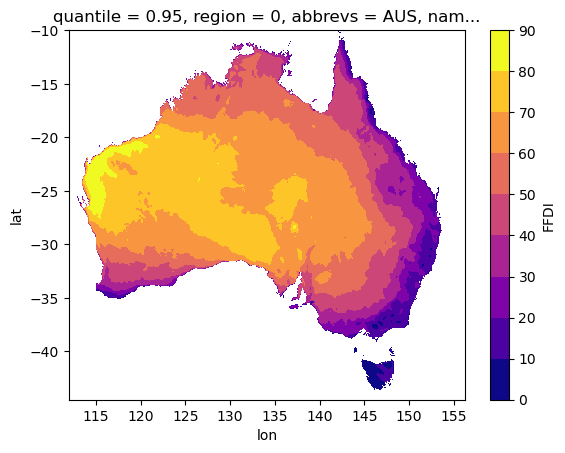

In [10]:
mask_ = mask_frac.isel(region=0)
d95=d95a.where(mask_).load()
d95.plot(cmap='plasma',levels=10)

In [11]:
df2=df0.sel(time=slice(t1,t2))
ds2=ds0.sel(time=slice(t1, t2))
dk2=dk0.sel(time=slice(t1,t2))
dd2=DF.sel(time=slice(t1,t2))
# extract only the values greater than FFDI > 95%
dfe95=df0.FFDI.where(df2.FFDI > d95)
dse95=ds0.where(df2.FFDI > d95)
dke95=dk0.where(df2.FFDI > d95)
dde95=DF.where(df2.FFDI > d95)

<xarray.DataArray (lat: 691, lon: 886, time: 7670)>
dask.array<where, shape=(691, 886, 7670), dtype=float32, chunksize=(33, 43, 7670), chunktype=numpy.ndarray>
Coordinates:
  * lat       (lat) float64 -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon       (lon) float64 112.0 112.0 112.1 112.2 ... 156.1 156.2 156.2 156.2
  * time      (time) datetime64[ns] 2015-01-01T12:00:00 ... 2035-12-31T12:00:00
    quantile  float64 0.95
    region    int64 0
    abbrevs   <U3 'AUS'
    names     <U9 'Australia'
Attributes:
    units:

In [12]:
%%time
# Only create file if it does not exist
outf='/scratch/xv83/rxm599/tmp_dde95.zarr'
outf='/scratch/xv83/rxm599/sa_2020/'+f'model_{mindex}_dde95.zarr'
outf='/scratch/xv83/rxm599/'+f'{dirstore}/'+f'model_{mindex}_dde95.zarr'
print(outf)
if os.path.exists(outf):
    print("File exists!")
    ddtmp=xr.open_zarr(outf)
else:
    print("File does not exist.")
    dde95.to_zarr(outf, mode='w')
    ddtmp=xr.open_zarr(outf)

/scratch/xv83/rxm599/sa_2020/model_0_dde95.zarr
File exists!
CPU times: user 115 ms, sys: 72.3 ms, total: 187 ms
Wall time: 1.32 s


In [13]:
#print(dde95)
var_name = list(ddtmp.data_vars)[0]
dde95 = ddtmp[var_name]
#dde95

In [14]:

if mindex != mobs: 
# for projections    
    tmax=dse95.tasmaxAdjust.sel(lon=slice(lon1,lon2),lat=slice(lat1,lat2 )) 
    hmin=dse95.hursminAdjust.sel( lon=slice(lon1,lon2),lat=slice(lat1,lat2 )) 
    wmax=dse95.sfcWindmaxAdjust.sel(lon=slice(lon1,lon2),lat=slice(lat1,lat2 )) 
else:
    tmax=dse95.tasmax.sel(lon=slice(lon1,lon2),lat=slice(lat1,lat2 )) 
    hmin=dse95.hursmin.sel( lon=slice(lon1,lon2),lat=slice(lat1,lat2 )) 
    wmax=dse95.sfcWindmax.sel(lon=slice(lon1,lon2),lat=slice(lat1,lat2 )) 
    
# ffdi 
di=dde95.sel(lon=slice(lon1,lon2),lat=slice(lat1,lat2 )) 
b=dfe95.sel(lon=slice(lon1,lon2),lat=slice(lat1,lat2 )) 
#di.max(axis=2).plot(cmap='plasma')
#di

## Fit PDF to use in Sobol calculation

In [90]:
# generic definitions of fitting function

# calculate min and remove it before fitting
ta=tmax.min(dim='time')
ha=hmin.min(dim='time')
da=di.min(dim='time')
wa=wmax.min(dim='time')

tmax1=tmax-ta
hmin1=hmin-ha
di1=di-da
wmax1=wmax-wa

tfit=sa.fit_gamma(tmax1)
hfit=sa.fit_gamma(hmin1)
dfit=sa.fit_gamma(di1)
wfit=sa.fit_gamma(wmax1)

tfit1=sa.fit_lognorm(tmax1)
hfit1=sa.fit_lognorm(hmin1)
dfit1=sa.fit_lognorm(di1)
wfit1=sa.fit_lognorm(wmax1)


%%time
tfit=sa.fit_beta(tmax).load()
hfit=sa.fit_beta(hmin).load()
dfit=sa.fit_gamma(di).load()
wfit=sa.fit_beta(wmax).load()

dfita=sa.fit_beta(di).load()
dfitb=sa.fit_lognorm(di).load()

In [ ]:
%%time
outf1='/scratch/xv83/rxm599/'+f'model_{mindex}_fits.zarr'
outf2='/scratch/xv83/rxm599/'+f'model_{mindex}_lfits.zarr'
print(mindex)
print(outf1)
tfit.name='tfit'
hfit.name='hfit'
wfit.name='wfit'
dfit.name='dfit'

tfit1.name='tfit'
hfit1.name='hfit'
wfit1.name='wfit'
dfit1.name='dfit'

ta.name='Tmax_min'
ha.name='Hmin_min'
da.name='DI_min'
wa.name='Wmax_min'

la=-30;lo=115.05
print(tfit.sel(lon=lo,lat=la).values)
print(tfit1.sel(lon=lo,lat=la).values)

#ds= xr.merge([ta,ha,da,wa])
ds = xr.merge([tfit,hfit,wfit,dfit,ta,ha,da,wa])  #,dfit,dfitb])
ds.to_zarr(outf1,mode='w')

ta.name='Tmax_min'
ha.name='Hmin_min'
da.name='DI_min'
wa.name='Wmax_min'

#ds = xr.merge([tfit,hfit,wfit,dfita,dfit,dfitb])
#ds= xr.merge([ta,ha,da,wa])
dslog = xr.merge([tfit1,hfit1,wfit1,dfit1])  #,dfit,dfitb])

dslog.to_zarr(outf2,mode='w')

0
/scratch/xv83/rxm599/model_0_fits.zarr
[ 1.26835745e+06 -3.58466516e+03  2.83164201e-03  2.56922561e-01
  7.70716447e-23]


/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:6120: RuntimeWarning: divide by zero encountered in log
  return np.sum((1 + np.log(shifted/scale)/shape**2)/shifted)


[ 1.46677144e-02 -2.07037404e+02  2.15713080e+02  3.42210964e-02
  7.46058802e-01]


2025-08-15 13:21:20,257 - distributed.nanny - WARNING - Restarting worker
2025-08-15 13:21:40,507 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('array-ba9e6e4f4a5af6f518352fb6139e232e', 0, 0, 0))" coro=<Worker.execute() done, defined at /g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/distributed/worker_state_machine.py:3615>> ended with CancelledError


## Read in fit results

In [17]:
%%time
ds1=0; ds2=0
outf1='/scratch/xv83/rxm599/'+f'model_{mindex}_fits.zarr'
print(mindex)
print(outf1)

ds1 = xr.open_zarr(outf1)

0
/scratch/xv83/rxm599/model_0_fits.zarr
CPU times: user 109 ms, sys: 68.5 ms, total: 178 ms
Wall time: 1.25 s


In [18]:
%%time
tfit=ds1.tfit.load()
hfit=ds1.hfit.load()
wfit=ds1.wfit.load()
dfit=ds1.dfit.load()

CPU times: user 8.28 s, sys: 1.21 s, total: 9.48 s
Wall time: 34.3 s


Text(0.5, 1.0, 'Wmax')

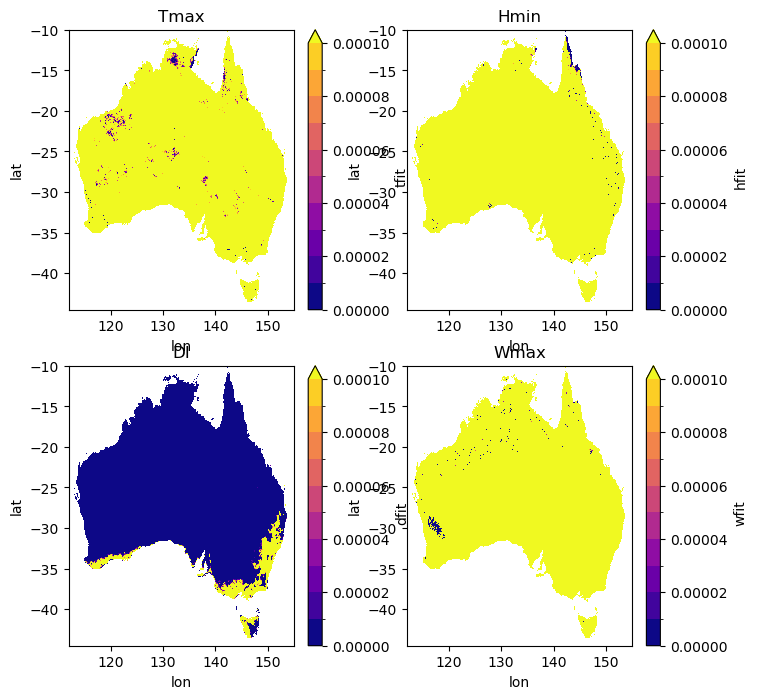

In [19]:
lev1=np.arange(0, 1, .1)
lev1 = np.linspace(0, .0001, 11)
plt.figure(figsize=(8, 8))
plt.subplot(2,2,1); tfit.sel(parameter1='p-value').plot(levels=lev1,cmap='plasma')
plt.title("Tmax")
plt.subplot(2,2,2); hfit.sel(parameter1='p-value').plot(levels=lev1,cmap='plasma')
plt.title("Hmin")
plt.subplot(2,2,3); dfit.sel(parameter1='p-value').plot(levels=lev1,cmap='plasma')
plt.title("DI")
plt.subplot(2,2,4); wfit.sel(parameter1='p-value').plot(levels=lev1,cmap='plasma')
plt.title("Wmax")

In [21]:
%%time

def bad(a11): # Find locations where condition is True
    locations = a11 < .0000002
# Stack dimensions into a flat index
    stacked = locations.stack(all_points=("lon", "lat"))
# Get the coordinates where the condition is True
    matching_indices = stacked.where(stacked, drop=True)
# Print the matching indices
#    print(matching_indices.coords)
    count = (matching_indices).sum().item()  # .item() to get Python scalar
    print('number of points=',count)
    return matching_indices

res=bad(tfit.sel(parameter1='p-value'))
res=bad(hfit.sel(parameter1='p-value'))
res=bad(dfit.sel(parameter1='p-value'))
res=bad(wfit.sel(parameter1='p-value'))


number of points= 352.0
number of points= 1187.0
number of points= 253490.0
number of points= 1481.0
CPU times: user 128 ms, sys: 29.7 ms, total: 157 ms
Wall time: 160 ms


### Do it again with lognorm fits

In [20]:
%%time
outf2='/scratch/xv83/rxm599/'+f'model_{mindex}_lfits.zarr'
print(mindex)
print(outf1)

ds2 = xr.open_zarr(outf2)

0
/scratch/xv83/rxm599/model_0_fits.zarr
CPU times: user 61.8 ms, sys: 38.1 ms, total: 99.9 ms
Wall time: 608 ms


In [21]:
%%time
tfit1=ds2.tfit.load()
hfit1=ds2.hfit.load()
wfit1=ds2.wfit.load()
dfit1=ds2.dfit.load()

CPU times: user 4.39 s, sys: 385 ms, total: 4.77 s
Wall time: 10 s


Text(0.5, 1.0, 'Wmax')

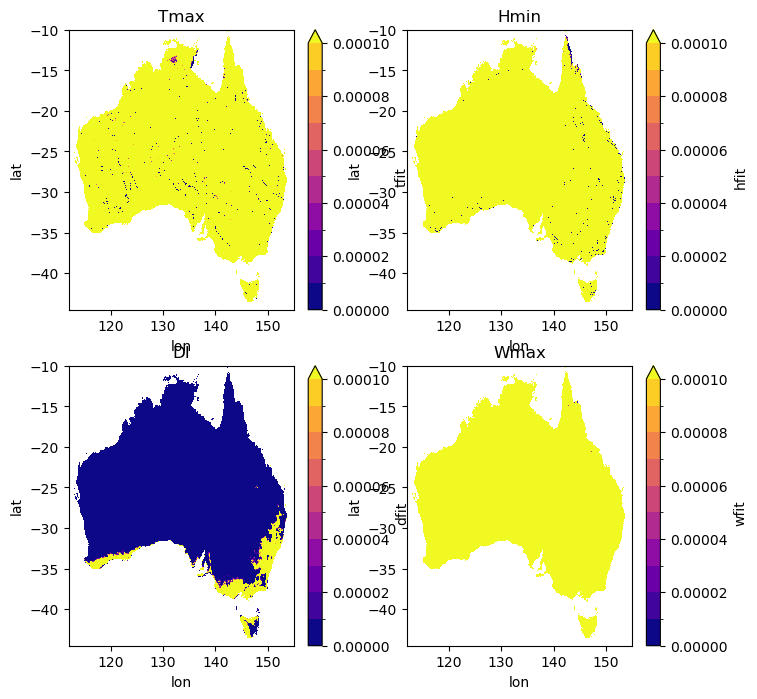

In [22]:
lev1=np.arange(0, 1, .1)
lev1 = np.linspace(0, .0001, 11)
plt.figure(figsize=(8, 8))
plt.subplot(2,2,1); tfit1.sel(parameter1='p-value').plot(levels=lev1,cmap='plasma')
plt.title("Tmax")
plt.subplot(2,2,2); hfit1.sel(parameter1='p-value').plot(levels=lev1,cmap='plasma')
plt.title("Hmin")
plt.subplot(2,2,3); dfit1.sel(parameter1='p-value').plot(levels=lev1,cmap='plasma')
plt.title("DI")
plt.subplot(2,2,4); wfit1.sel(parameter1='p-value').plot(levels=lev1,cmap='plasma')
plt.title("Wmax")

In [ ]:
%%time

res=bad(tfit1.sel(parameter1='p-value'))
res=bad(hfit1.sel(parameter1='p-value'))
res=bad(dfit1.sel(parameter1='p-value'))
res=bad(wfit1.sel(parameter1='p-value'))


In [24]:
a1=(tfit.sel(parameter1='p-value') - tfit1.sel(parameter1='p-value'))
#a1.max().values
la=-30;lo=115.05
print(tfit.sel(lon=lo,lat=la).values)
print(tfit1.sel(lon=lo,lat=la).values)

[ 1.26835745e+06 -3.58466516e+03  2.83164201e-03  2.56922561e-01
  7.70716447e-23]
[ 1.46677144e-02 -2.07037404e+02  2.15713080e+02  3.42210964e-02
  7.46058802e-01]


In [25]:
a1=wfit.sel(parameter1='p-value')
a2=wfit1.sel(parameter1='p-value')
b=xr.apply_ufunc(np.maximum, a1, a2)
res=bad(b)
a1=tfit.sel(parameter1='p-value')
a2=tfit1.sel(parameter1='p-value')
b=xr.apply_ufunc(np.maximum, a1, a2)
res=bad(b)
a1=hfit.sel(parameter1='p-value')
a2=hfit1.sel(parameter1='p-value')
b=xr.apply_ufunc(np.maximum, a1, a2)
res=bad(b)
a1=dfit.sel(parameter1='p-value')
a2=dfit1.sel(parameter1='p-value')
b=xr.apply_ufunc(np.maximum, a1, a2)
res=bad(b)

number of points= 0.0
number of points= 68.0
number of points= 160.0
number of points= 250919.0


In [ ]:
sys.exit(1)

## Testing fit to a location 

In [29]:
la=-30;lo=115.05
#tmp1=di1.sel(lat=la,lon=lo).load()
tmp1=tmax1.sel(lat=la,lon=lo).load()
#tmp1=wmax1.sel(lat=la,lon=lo).load()
#tmp1=hmin1.sel(lat=la,lon=lo).load()
dfita=sa.fit_gamma(tmp1)
dfitb=sa.fit_invgauss(tmp1)
dfitc=sa.fit_lognorm(tmp1)

dfit1a=dfita.load()
dfit1b=dfitb.load()
dfit1c=dfitc.load()
#print(dfit1a)
#dfit1=dfit.sel(lat=la,lon=lo).load()
#dfit1a=dfita.sel(lat=la,lon=lo).load()
#dfit1b=dfitb.sel(lat=la,lon=lo).load()

<xarray.DataArray 'gamma_params' (parameter1: 5)>
array([ 1.26835745e+06, -3.58466516e+03,  2.83164201e-03,  2.56922561e-01,
        7.70716447e-23])
Coordinates:
    lat         float64 -30.0
    lon         float64 115.0
    quantile    float64 0.95
    region      int64 0
    abbrevs     <U3 'AUS'
    names       <U9 'Australia'
  * parameter1  (parameter1) <U7 'a' 'loc' 'scale' 'KS-fit' 'p-value'
<xarray.DataArray 'invgauss_params' (parameter1: 5)>
array([ 2.54163314e-02, -1.21844138e+01,  8.20936976e+02,  6.55450457e-02,
        7.05576040e-02])
Coordinates:
    lat         float64 -30.0
    lon         float64 115.0
    quantile    float64 0.95
    region      int64 0
    abbrevs     <U3 'AUS'
    names       <U9 'Australia'
  * parameter1  (parameter1) <U7 'a' 'loc' 'scale' 'KS-fit' 'p-value'
<xarray.DataArray 'lognorm_params' (parameter1: 5)>
array([ 1.46677144e-02, -2.07037404e+02,  2.15713080e+02,  3.42210964e-02,
        7.46058802e-01])
Coordinates:
    lat         float64 

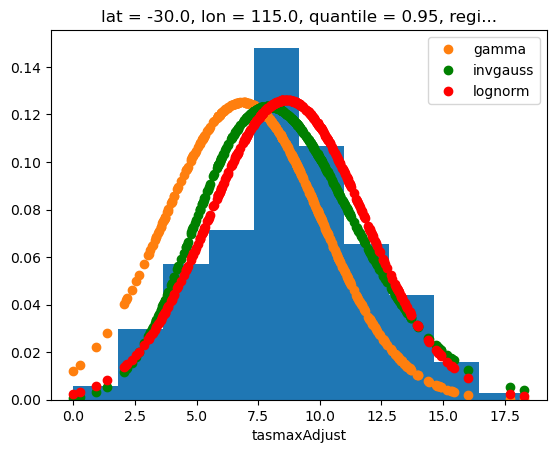

In [30]:
%%time
# Testing the fitting at one location by comparing beta and gamma fits
from scipy.stats import beta, kstest, gamma, lognorm, invgauss
#tmp1=tmax.sel(lat=la,lon=lo).load()
#tmp1=tmp1-tmp1.min()

print(dfit1a)
print(dfit1b)
print(dfit1c)
tmp1.plot.hist(density=True)

rvb=invgauss(dfit1b.sel(parameter1='a'),
        dfit1b.sel(parameter1='loc'),dfit1b.sel(parameter1='scale') )
rvg=gamma(dfit1a.sel(parameter1='a'),
        dfit1a.sel(parameter1='loc'),dfit1a.sel(parameter1='scale') )
rvl=lognorm(dfit1c.sel(parameter1='a'),
        dfit1c.sel(parameter1='loc'),dfit1c.sel(parameter1='scale') )
plt.plot(tmp1,rvg.pdf(tmp1),'o',label='gamma')
plt.plot(tmp1,rvb.pdf(tmp1),'go',label='invgauss')
plt.plot(tmp1,rvl.pdf(tmp1),'ro',label='lognorm')
plt.legend()


In [73]:
#client.shutdown()